# Manipulating pyclesperanto arrays

This notebook illustrates the basic ways a `pyclesperanto.Array` can be manipulated:
create, copy, crop, transpose, paste, dtype conversion, and slicing.

We first do this with a small synthetic array, then repeat the same operations on a real
image loaded with `scikit-image`.

In [1]:
import numpy as np
import pyclesperanto as cle

cle.select_device()

(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

## 1. Create

Arrays can be created from scratch (`zeros`, `ones`, `full`, `create`/`empty`) or pushed from
an existing NumPy array.

In [2]:
data = np.arange(30, dtype=np.float32).reshape(5, 6)
arr = cle.push(data)
arr

array([[ 0.,  1.,  2.,  3.,  4.,  5.],
       [ 6.,  7.,  8.,  9., 10., 11.],
       [12., 13., 14., 15., 16., 17.],
       [18., 19., 20., 21., 22., 23.],
       [24., 25., 26., 27., 28., 29.]], dtype=float32, mtype=buffer)

## 2. Copy

`.copy()` returns an independent array on the device: modifying the copy does not affect the
original.

In [3]:
arr_copy = arr.copy()
arr_copy[0, 0] = -1
arr_copy, arr

(array([[-1.,  1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10., 11.],
        [12., 13., 14., 15., 16., 17.],
        [18., 19., 20., 21., 22., 23.],
        [24., 25., 26., 27., 28., 29.]], dtype=float32, mtype=buffer),
 array([[ 0.,  1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10., 11.],
        [12., 13., 14., 15., 16., 17.],
        [18., 19., 20., 21., 22., 23.],
        [24., 25., 26., 27., 28., 29.]], dtype=float32, mtype=buffer))

## 3. Crop

`cle.crop()` extracts a sub-region defined by an origin `(start_x, start_y, start_z)` and a
size `(width, height, depth)`.

In [4]:
tile = cle.crop(arr, start_x=1, start_y=1, width=3, height=2)
tile

array([[ 7.,  8.,  9.],
       [13., 14., 15.]], dtype=float32, mtype=buffer)

## 4. Transpose

`.T` transposes the array, same as in NumPy.

In [5]:
arr.T

array([[ 0.,  6., 12., 18., 24.],
       [ 1.,  7., 13., 19., 25.],
       [ 2.,  8., 14., 20., 26.],
       [ 3.,  9., 15., 21., 27.],
       [ 4., 10., 16., 22., 28.],
       [ 5., 11., 17., 23., 29.]], dtype=float32, mtype=buffer)

## 5. Paste

`cle.paste()` writes an array into another array at a given destination position.

In [6]:
canvas = cle.create(arr.shape, dtype=arr.dtype)
canvas.fill(0)
cle.paste(tile, canvas, destination_x=0, destination_y=0)
canvas

array([[ 7.,  8.,  9.,  0.,  0.,  0.],
       [13., 14., 15.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.]], dtype=float32, mtype=buffer)

## 6. dtype conversion

`.astype()` converts the array to another dtype, following NumPy semantics.

In [7]:
arr_uint8 = arr.astype(np.uint8)
arr_uint8.dtype

dtype('uint8')

## 7. Slicing

Standard NumPy-style slicing works for both reading and assignment.

In [8]:
arr[1:3, 2:5]

array([[ 8.,  9., 10.],
       [14., 15., 16.]], dtype=float32, mtype=buffer)

In [9]:
sliced = arr.copy()
sliced[0, :] = 100
sliced

array([[100., 100., 100., 100., 100., 100.],
       [  6.,   7.,   8.,   9.,  10.,  11.],
       [ 12.,  13.,  14.,  15.,  16.,  17.],
       [ 18.,  19.,  20.,  21.,  22.,  23.],
       [ 24.,  25.,  26.,  27.,  28.,  29.]], dtype=float32, mtype=buffer)

---

## Same operations, on a real image

We now repeat create / copy / crop / transpose / paste / dtype conversion / slicing, replacing
the synthetic array with the `blobs.png` sample image read via `scikit-image`.

array([[ 40,  32,  24, ..., 216, 200, 200],
       [ 56,  40,  24, ..., 232, 216, 216],
       [ 64,  48,  24, ..., 240, 232, 232],
       ...,
       [ 72,  80,  80, ...,  48,  48,  48],
       [ 80,  80,  80, ...,  48,  48,  48],
       [ 96,  88,  80, ...,  48,  48,  48]], shape=(254, 256), dtype=uint8, mtype=buffer)
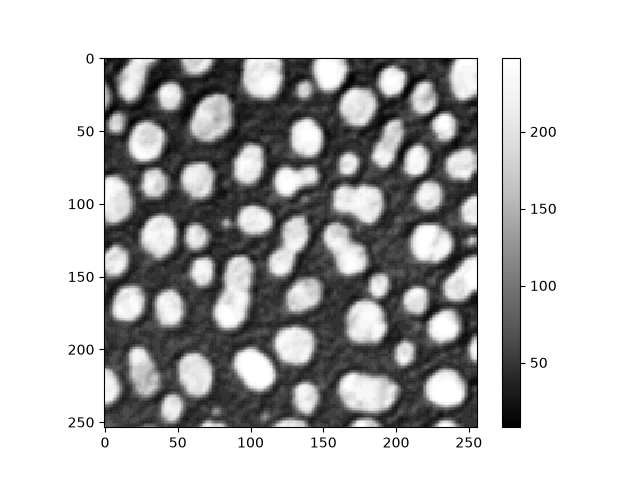
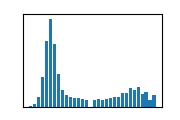

In [10]:
from skimage.io import imread

image = cle.push(imread("https://samples.fiji.sc/blobs.png").squeeze())
image

### Copy

array([[ 40,  32,  24, ..., 216, 200, 200],
       [ 56,  40,  24, ..., 232, 216, 216],
       [ 64,  48,  24, ..., 240, 232, 232],
       ...,
       [ 72,  80,  80, ...,  48,  48,  48],
       [ 80,  80,  80, ...,  48,  48,  48],
       [ 96,  88,  80, ...,  48,  48,  48]], shape=(254, 256), dtype=uint8, mtype=buffer)
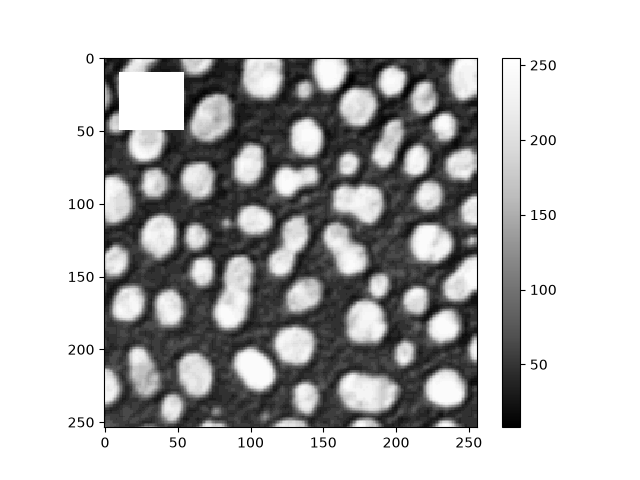
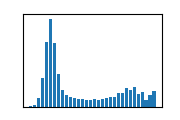

In [18]:
image_copy = image.copy()
image_copy[10:50, 10:55] = 255
image_copy

array([[ 40,  32,  24, ..., 216, 200, 200],
       [ 56,  40,  24, ..., 232, 216, 216],
       [ 64,  48,  24, ..., 240, 232, 232],
       ...,
       [ 72,  80,  80, ...,  48,  48,  48],
       [ 80,  80,  80, ...,  48,  48,  48],
       [ 96,  88,  80, ...,  48,  48,  48]], shape=(254, 256), dtype=uint8, mtype=buffer)
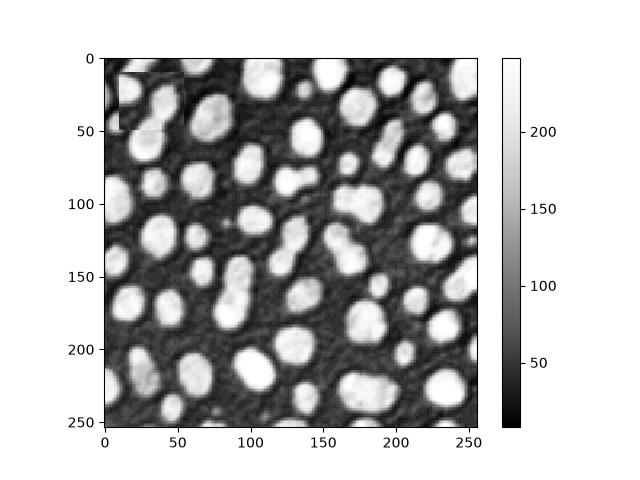
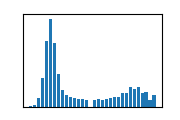

In [24]:
image_copy = image.copy()
image_copy[10:50, 10:55] = image[100:150, 100:155]
image_copy

### Crop

array([[ 64, 104, 136, ...,  32,  40,  40],
       [ 88, 112, 144, ...,  32,  40,  40],
       [104, 128, 144, ...,  32,  40,  40],
       ...,
       [112,  96,  72, ...,  32,  40,  40],
       [144, 120,  96, ...,  40,  48,  48],
       [168, 144, 120, ...,  48,  56,  56]], shape=(75, 75), dtype=uint8, mtype=buffer)
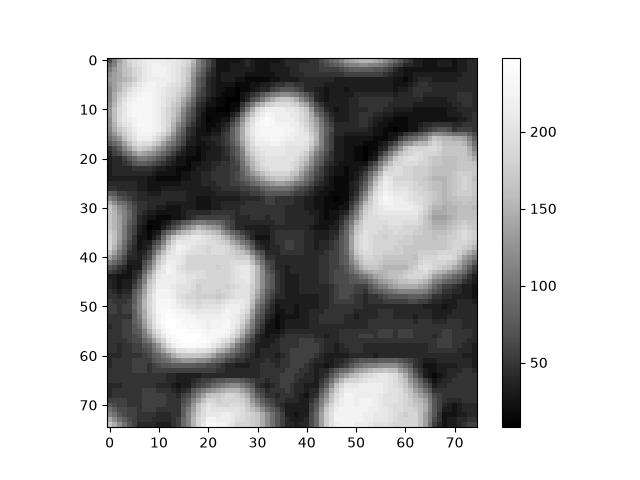
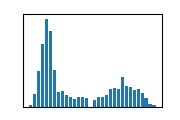

In [12]:
width, height = 75, 75
x, y = 10, 10
tile = cle.crop(image, start_x=x, start_y=y, width=width, height=height)
tile

### Transpose

array([[ 40,  56,  64, ...,  72,  80,  96],
       [ 32,  40,  48, ...,  80,  80,  88],
       [ 24,  24,  24, ...,  80,  80,  80],
       ...,
       [216, 232, 240, ...,  48,  48,  48],
       [200, 216, 232, ...,  48,  48,  48],
       [200, 216, 232, ...,  48,  48,  48]], shape=(256, 254), dtype=uint8, mtype=buffer)
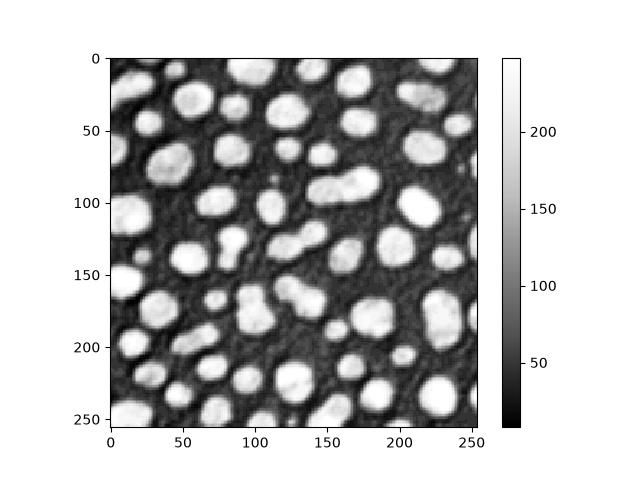
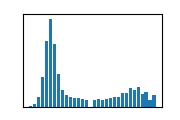

In [13]:
image.T

### Paste

array([[ 64, 104, 136, ...,   0,   0,   0],
       [ 88, 112, 144, ...,   0,   0,   0],
       [104, 128, 144, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,  32,  40,  40],
       [  0,   0,   0, ...,  40,  48,  48],
       [  0,   0,   0, ...,  48,  56,  56]], shape=(150, 150), dtype=uint8, mtype=buffer)
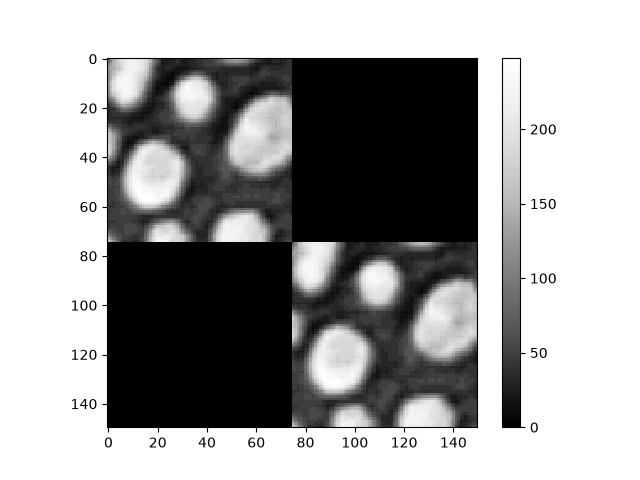
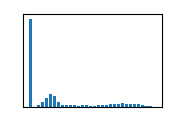

In [14]:
canvas = cle.create((width * 2, height * 2), dtype=tile.dtype)
canvas.fill(0)
cle.paste(tile, canvas, destination_x=0, destination_y=0)
cle.paste(tile, canvas, destination_x=width, destination_y=height)
canvas

### dtype conversion

In [15]:
image_float = image.astype(np.float32)
image_float.dtype

dtype('float32')

### Slicing

array([[ 64, 104, 136, ..., 112, 128, 136],
       [ 88, 112, 144, ...,  88, 104, 112],
       [104, 128, 144, ...,  64,  72,  80],
       ...,
       [ 48,  40,  32, ...,  64,  64,  64],
       [ 48,  48,  40, ...,  64,  64,  56],
       [ 56,  48,  48, ...,  56,  56,  56]], shape=(50, 50), dtype=uint8, mtype=buffer)
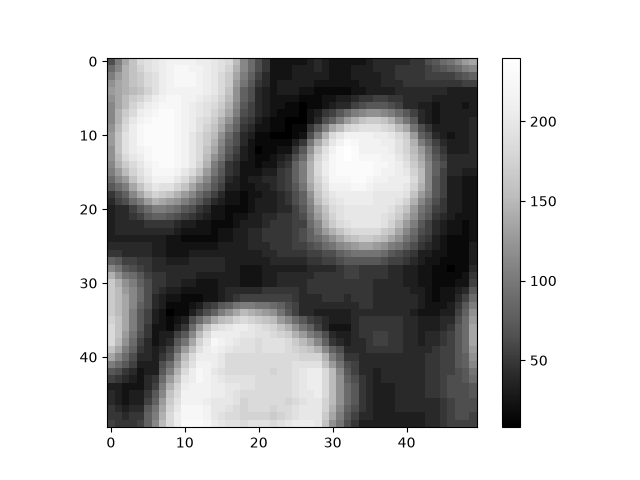
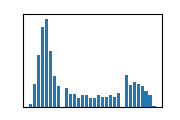

In [21]:
image[10:60, 10:60]

array([[ 40,  24,  24, ..., 216, 240, 200],
       [ 24,  48,  16, ..., 248, 240, 232],
       [ 48,  32,  64, ..., 224, 232, 216],
       ...,
       [ 72,  48,  40, ...,  40,  48,  48],
       [ 48,  56,  48, ...,  56,  48,  56],
       [ 64,  64,  56, ...,  48,  48,  48]], shape=(51, 52), dtype=uint8, mtype=buffer)
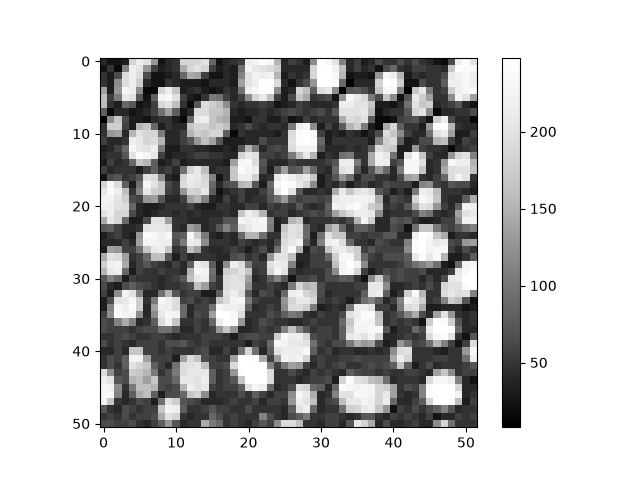
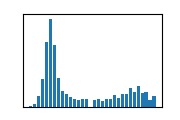

In [20]:
image[::5, ::5]